# Ridge , Lasso & ElasticNet Regression

## Algerian FOrest Fires Dataset 
Data Set Information: 

The dataset incluedes 244 instances that regroup a data of two regions of . Algeria namely the bejaia region located in the northest of algeria and the SIde bel-abbes region located in the northwest of Algeria. 

122 instances for each region.

The peroid from june 2012 to september 2012. THe dataset includes 11 attributes and 1 output attribute (class) The 244 instances have been classified into fire (138 classes) and not fire (106 classes ) classes.


 #### Attribute Information : 
 1. Date: (DD/MM/YYYY) day , month('june' to 'september') year (2012) Weather data observations
 2. Temp : Temperature noon (temperature max ) in celcius degrees 22 to 42
 3. RH : Relative Humidity in %: 21 to 90
 4. Ws : WInd speed in km/h: 6 to 29
 5. Rain : Total day in mm: 0 to 16.8 FWI Components
 6. FIne Fule Moisture Code (FFMC) incesx from the FWI system : 28.6 to 92.5
 7. Duff Moisture code(DMC) index from the FWI system 1.1 to 65.9
 8. Drough code (DC) index from the FWI system : 7 to 220.4
 9. Initial Spread Index (ISI) index from the FWI system : 0  to 18.5
 10. 10 BUildp Index (BUI) index from the FWI system : 1.1 to 68
 11. Fire Weather index FWI) index : 0 to 31.1
 12. Classes : two classes , namely fire and not fire
 13. 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 


In [2]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
df.head()

,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        242 non-null    int64  
 1   day          242 non-null    int64  
 2   month        242 non-null    int64  
 3   year         242 non-null    int64  
 4   Temperature  242 non-null    int64  
 5   RH           242 non-null    int64  
 6   Ws           242 non-null    int64  
 7   Rain         242 non-null    float64
 8   FFMC         242 non-null    float64
 9   DMC          242 non-null    float64
 10  DC           242 non-null    float64
 11  ISI          242 non-null    float64
 12  BUI          242 non-null    float64
 13  FWI          242 non-null    float64
 14  Classes      242 non-null    object 
 15  Region       242 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.4+ KB


## Data Cleaning 

In [4]:
## check missing value 
df.isnull().sum()

index          0
day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

The Dataset is converted into two sets based on the region from 122th index, we can make a new column based on the Region 

1: "Bajaia Region Dataset"

2: "Sidi-bel Abbes Resion Dataset

Add new column with Region 

In [5]:
df.loc[:122,'Region']=0
df.loc[122:,'Region']=1

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        242 non-null    int64  
 1   day          242 non-null    int64  
 2   month        242 non-null    int64  
 3   year         242 non-null    int64  
 4   Temperature  242 non-null    int64  
 5   RH           242 non-null    int64  
 6   Ws           242 non-null    int64  
 7   Rain         242 non-null    float64
 8   FFMC         242 non-null    float64
 9   DMC          242 non-null    float64
 10  DC           242 non-null    float64
 11  ISI          242 non-null    float64
 12  BUI          242 non-null    float64
 13  FWI          242 non-null    float64
 14  Classes      242 non-null    object 
 15  Region       242 non-null    int64  
dtypes: float64(7), int64(8), object(1)
memory usage: 30.4+ KB


In [7]:
df[['Region']]=df[['Region']].astype(int)

In [8]:
# Removeing the null values 
df=df.dropna().reset_index()

In [9]:
df.isnull().sum()

level_0        0
index          0
day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [10]:
df.iloc[[112]]

,level_0,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
112,112,112,21,9,2012,31,55,11,0.0,87.8,16.5,57.9,5.4,19.2,8.3,fire,0


In [11]:
# Remove the 122 nd row
df=df.drop(122).reset_index(drop=True)
df.iloc[[122]]

,level_0,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,123,124,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire,1


In [12]:
## fix spaces in columns name 
df.columns =df.columns.str.strip()
df.columns

Index(['level_0', 'index', 'day', 'month', 'year', 'Temperature', 'RH', 'Ws',
       'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   level_0      241 non-null    int64  
 1   index        241 non-null    int64  
 2   day          241 non-null    int64  
 3   month        241 non-null    int64  
 4   year         241 non-null    int64  
 5   Temperature  241 non-null    int64  
 6   RH           241 non-null    int64  
 7   Ws           241 non-null    int64  
 8   Rain         241 non-null    float64
 9   FFMC         241 non-null    float64
 10  DMC          241 non-null    float64
 11  DC           241 non-null    float64
 12  ISI          241 non-null    float64
 13  BUI          241 non-null    float64
 14  FWI          241 non-null    float64
 15  Classes      241 non-null    object 
 16  Region       241 non-null    int64  
dtypes: float64(7), int64(9), object(1)
memory usage: 32.1+ KB


### changes the Required columns as integer data type 

In [14]:
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)

#### changing the other columns to float datatype 

In [15]:
objects=[features for features in df.columns  if df[features].dtypes=='0']


In [16]:
for i in objects:
    if i!='Classes':
        df[i]=df[i].astype(float)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   level_0      241 non-null    int64  
 1   index        241 non-null    int64  
 2   day          241 non-null    int64  
 3   month        241 non-null    int64  
 4   year         241 non-null    int64  
 5   Temperature  241 non-null    int64  
 6   RH           241 non-null    int64  
 7   Ws           241 non-null    int64  
 8   Rain         241 non-null    float64
 9   FFMC         241 non-null    float64
 10  DMC          241 non-null    float64
 11  DC           241 non-null    float64
 12  ISI          241 non-null    float64
 13  BUI          241 non-null    float64
 14  FWI          241 non-null    float64
 15  Classes      241 non-null    object 
 16  Region       241 non-null    int64  
dtypes: float64(7), int64(9), object(1)
memory usage: 32.1+ KB


In [18]:
df.describe()

,level_0,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,241.000000,241.000000,241.000000,241.000000,241.0,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,120.493776,120.987552,15.879668,7.514523,2012.0,32.161826,61.958506,15.518672,0.749793,78.020332,14.780913,49.774689,4.776763,16.805394,7.092116,0.493776
std,70.149193,70.584375,8.782442,1.110929,0.0,3.640449,14.861525,2.809334,2.000607,14.274480,12.395199,47.712892,4.154190,14.231143,7.445187,0.501002
min,0.000000,0.000000,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,60.000000,60.000000,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.600000,5.800000,14.700000,1.400000,6.100000,0.800000,0.000000
50%,120.000000,120.000000,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.700000,11.300000,33.400000,3.500000,12.500000,4.700000,0.000000
75%,181.000000,182.000000,23.000000,8.000000,2012.0,35.000000,74.000000,17.000000,0.500000,88.300000,20.900000,71.000000,7.300000,22.900000,11.600000,1.000000
max,241.000000,242.000000,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [19]:
## Let ave the cleaned Dataset 
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv',index=False)


## Exploratory Data Analysis 

In [20]:
# Drop day , month , year and index 
df_copy=df.drop(['day','month','year','index'],axis=1)

In [21]:

df_copy.head()

,level_0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [22]:
## Encoding of the categories in class

df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [23]:
df_copy.head()

,level_0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [24]:

df_copy['Classes'].value_counts()

Classes
1    137
0    104
Name: count, dtype: int64

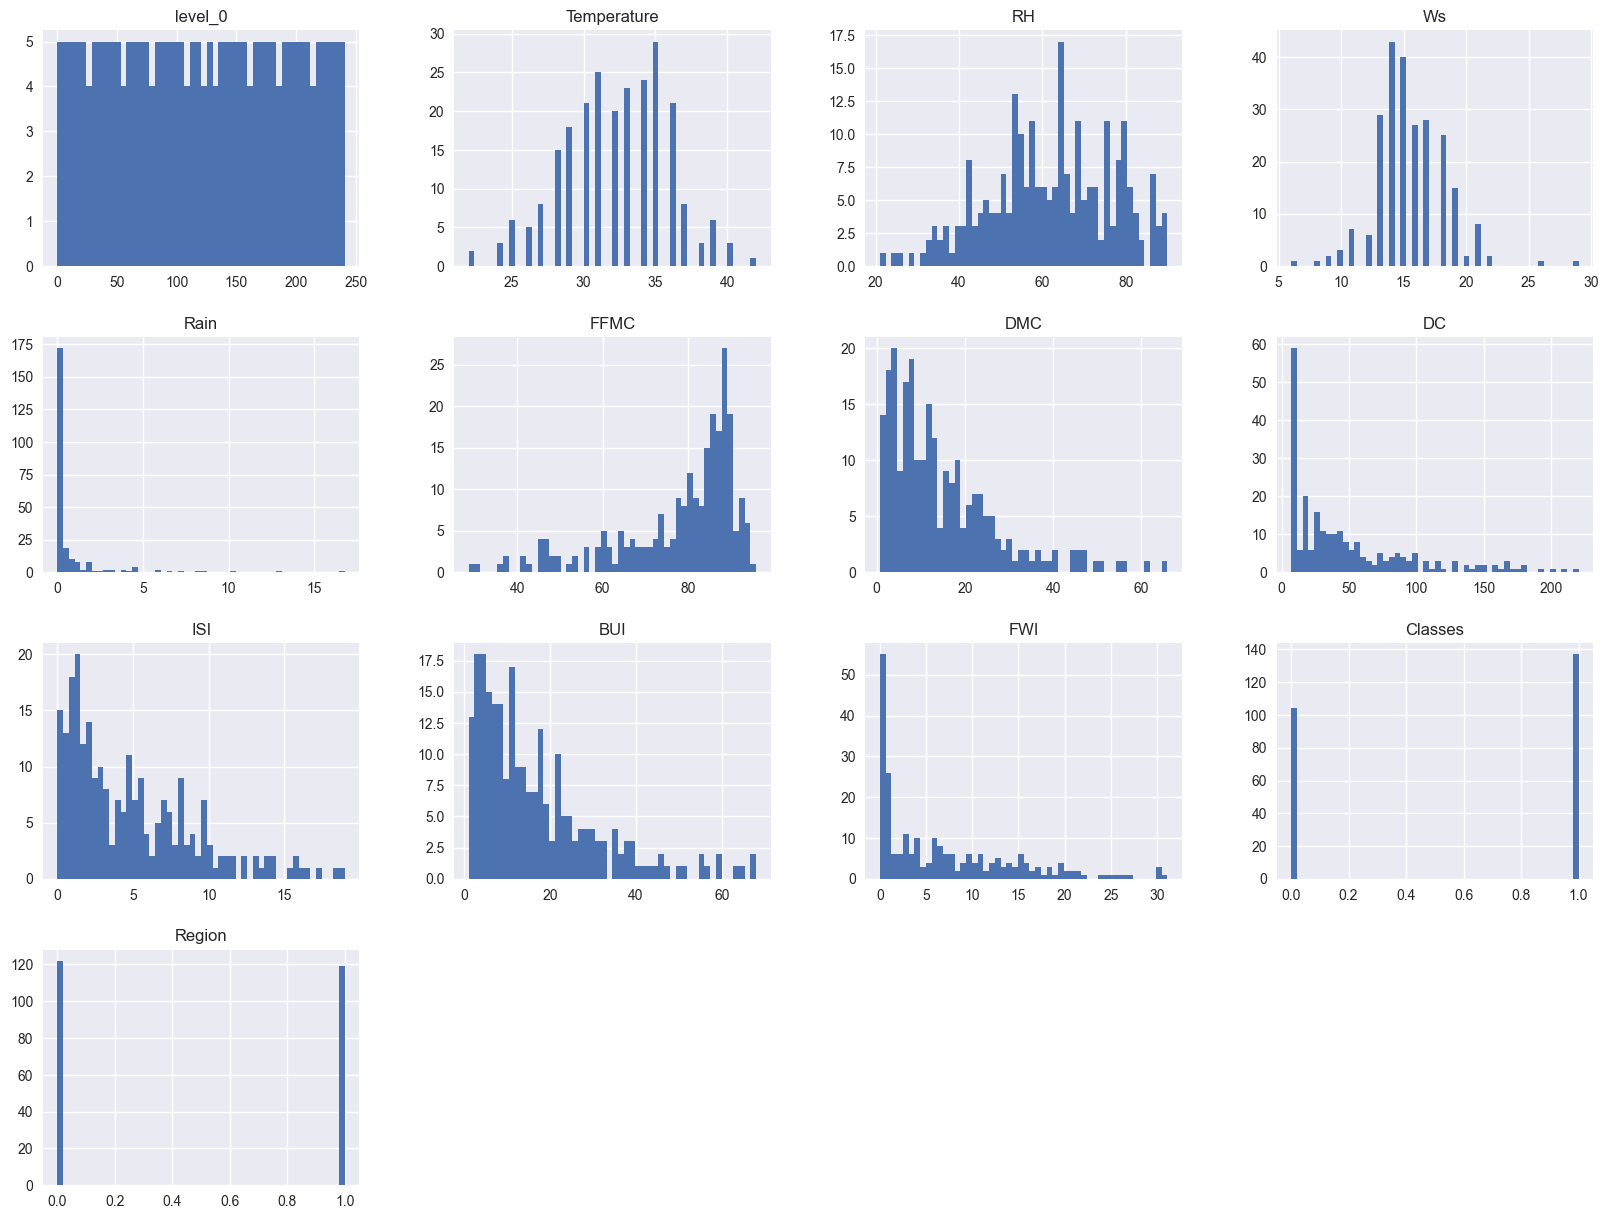

In [25]:
## Plot Density plot for all Features 
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [26]:
## Percentage for pie Chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

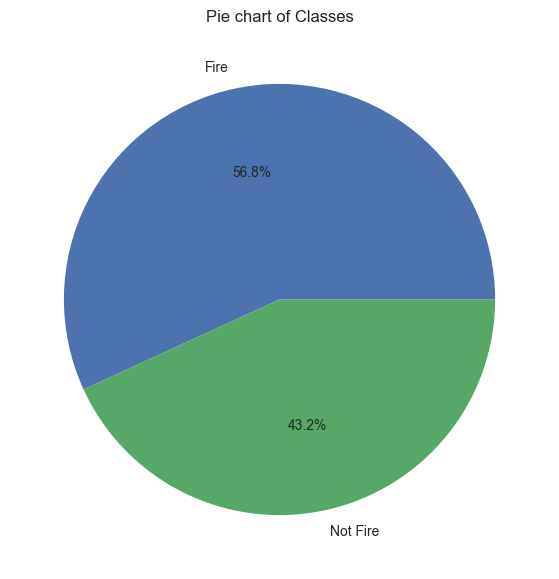

In [27]:
## plotting piechart 
classlabels=['Fire','Not Fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Pie chart of Classes')
plt.show()

## Correlation 

In [28]:
df_copy.corr()

,level_0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
level_0,1.000000,0.215447,-0.377526,-0.170807,-0.030813,0.229019,0.259802,0.058687,0.281380,0.182544,0.253634,0.177041,0.867746
Temperature,0.215447,1.000000,-0.651184,-0.288538,-0.324519,0.679353,0.485406,0.375432,0.604182,0.459374,0.566649,0.516166,0.273554
RH,-0.377526,-0.651184,1.000000,0.251609,0.219067,-0.643718,-0.405444,-0.223201,-0.685228,-0.350446,-0.578951,-0.428928,-0.410789
Ws,-0.170807,-0.288538,0.251609,1.000000,0.179167,-0.182322,-0.009466,0.072004,-0.000320,0.023004,0.024420,-0.080857,-0.173839
Rain,-0.030813,-0.324519,0.219067,0.179167,1.000000,-0.541693,-0.285066,-0.294782,-0.344192,-0.296227,-0.321227,-0.375657,-0.047080
FFMC,0.229019,0.679353,-0.643718,-0.182322,-0.541693,1.000000,0.599438,0.502847,0.737525,0.587699,0.688538,0.766622,0.237933
DMC,0.259802,0.485406,-0.405444,-0.009466,-0.285066,0.599438,1.000000,0.875084,0.677847,0.982107,0.874943,0.581867,0.201872
DC,0.058687,0.375432,-0.223201,0.072004,-0.294782,0.502847,0.875084,1.000000,0.505104,0.941620,0.737783,0.507224,-0.072004
ISI,0.281380,0.604182,-0.685228,-0.000320,-0.344192,0.737525,0.677847,0.505104,1.000000,0.641194,0.922326,0.732736,0.273803
BUI,0.182544,0.459374,-0.350446,0.023004,-0.296227,0.587699,0.982107,0.941620,0.641194,1.000000,0.856918,0.582868,0.098330


<Axes: >

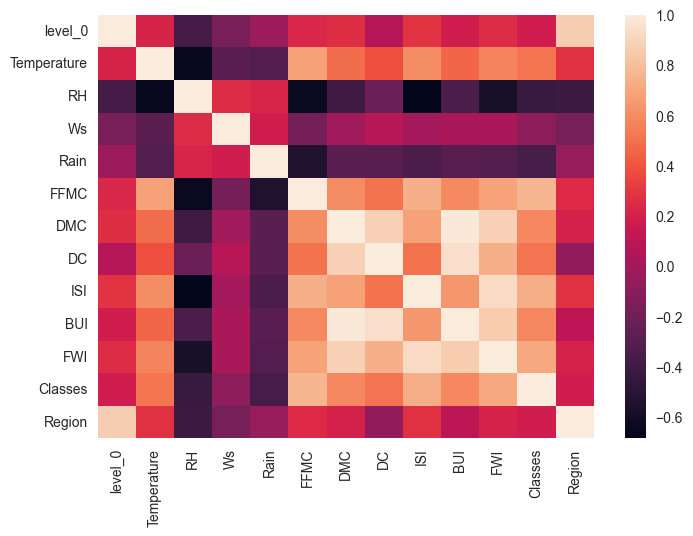

In [29]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

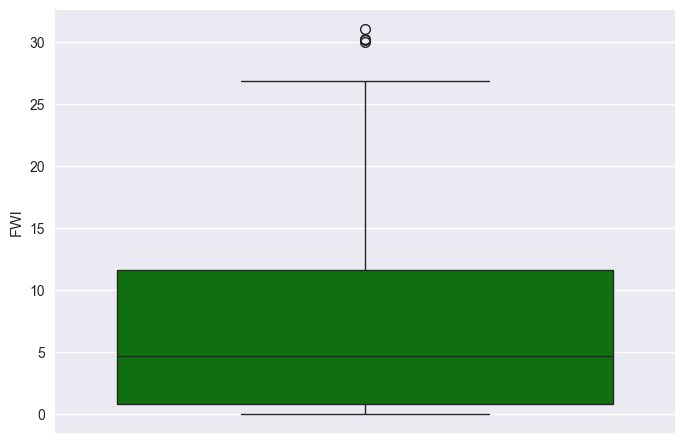

In [30]:
## box plots
sns.boxplot(df['FWI'],color='green')

Text(0.5, 1.0, 'Fire Analysis of  Bejaia Regions ')

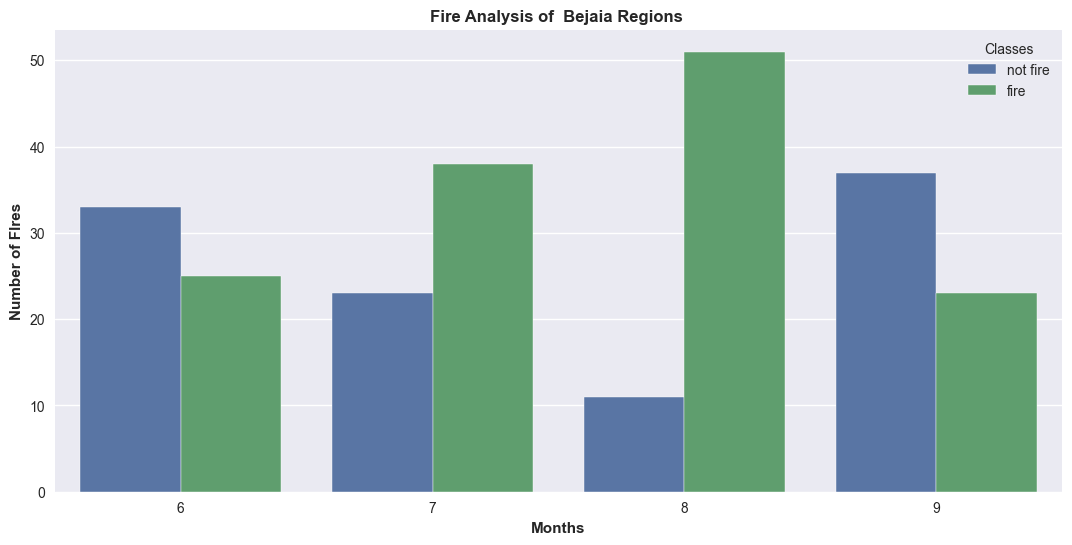

In [31]:
## Monthly fire analysis
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')
dftemp=df.loc[df['Region']==1]

plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)

plt.ylabel('Number of FIres',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title('Fire Analysis of  Bejaia Regions ', weight='bold')

Text(0.5, 1.0, 'Fire Analysis of  Sidi- Bel Regions ')

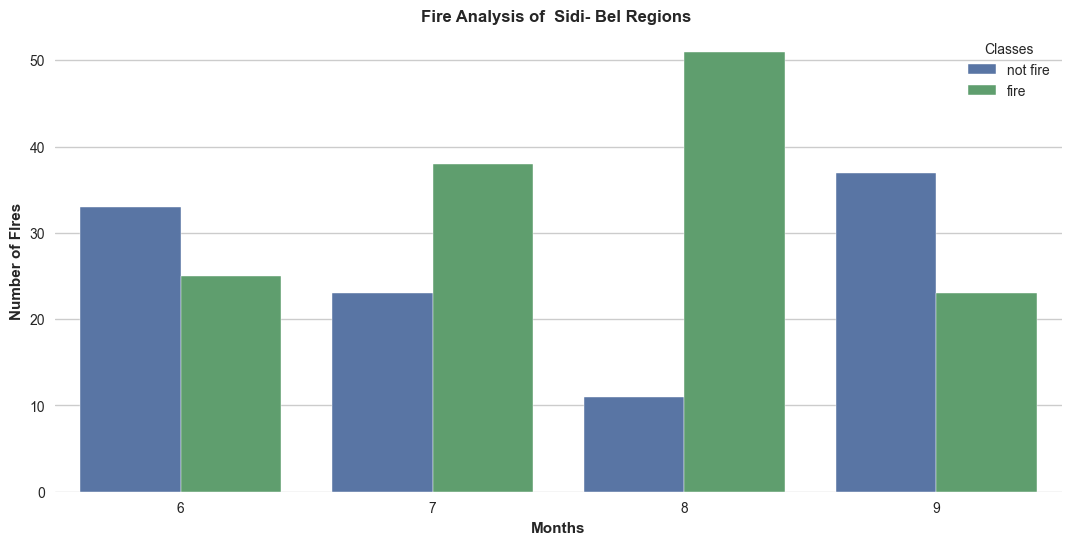

In [32]:
dftemp=df.loc[df['Region']==0]

plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)

plt.ylabel('Number of FIres',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title('Fire Analysis of  Sidi- Bel Regions ', weight='bold')

Its Observed that August and September had the most number of forest fires for both regions. ANd from the above plot of months, we can understand few things 

Most of the fires happened in August and very high Fires happened in only 3 month- June , July and August 

Less Fires was on September 

## Model Training 

In [33]:
x=df_copy.drop('FWI',axis=1)
y=df['FWI']


In [34]:
x

,level_0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
236,237,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
237,238,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
238,239,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
239,240,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [35]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
236    6.5
237    0.0
238    0.2
239    0.7
240    0.5
Name: FWI, Length: 241, dtype: float64

In [36]:
## Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [37]:
x_test.shape,x_train.shape

((61, 12), (180, 12))

In [38]:
## Feature Selection based on correlation 
x_train.corr()

,level_0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
level_0,1.000000,0.196606,-0.355048,-0.203752,-0.078224,0.240513,0.258925,0.045416,0.287747,0.184028,0.185005,0.865971
Temperature,0.196606,1.000000,-0.658884,-0.283527,-0.329838,0.695701,0.490708,0.368994,0.609129,0.461458,0.529054,0.254575
RH,-0.355048,-0.658884,1.000000,0.255366,0.218938,-0.636912,-0.383872,-0.201891,-0.687823,-0.330053,-0.429008,-0.388707
Ws,-0.203752,-0.283527,0.255366,1.000000,0.315301,-0.191422,-0.012974,0.078715,0.009717,0.020902,-0.088843,-0.199183
Rain,-0.078224,-0.329838,0.218938,0.315301,1.000000,-0.532895,-0.266456,-0.284452,-0.324347,-0.277710,-0.343453,-0.104973
FFMC,0.240513,0.695701,-0.636912,-0.191422,-0.532895,1.000000,0.598514,0.504184,0.733343,0.584447,0.763900,0.266560
DMC,0.258925,0.490708,-0.383872,-0.012974,-0.266456,0.598514,1.000000,0.878344,0.665321,0.984121,0.589805,0.207122
DC,0.045416,0.368994,-0.201891,0.078715,-0.284452,0.504184,0.878344,1.000000,0.508745,0.947259,0.502396,-0.084035
ISI,0.287747,0.609129,-0.687823,0.009717,-0.324347,0.733343,0.665321,0.508745,1.000000,0.628279,0.727029,0.282773
BUI,0.184028,0.461458,-0.330053,0.020902,-0.277710,0.584447,0.984121,0.947259,0.628279,1.000000,0.578800,0.104204


<Axes: >

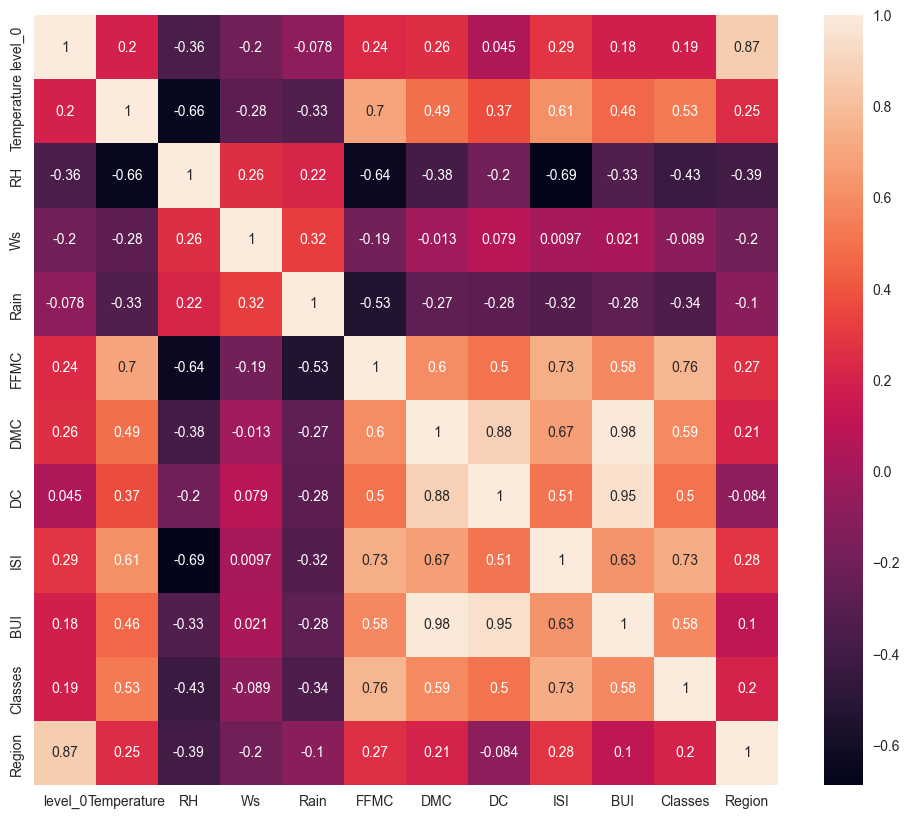

In [39]:
## Check for Multicollinearity 
plt.figure(figsize=(12,10))
corr=x_train.corr()
sns.heatmap(corr,annot=True)

In [40]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [41]:
# THreshold--Domain expertise 

correlation(x_train,0.85)

{'BUI', 'DC', 'Region'}

In [42]:
## Drip features when correlation is more the 0.85
corr_features=correlation(x_train,0.85)

In [43]:
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)

In [44]:
x_train.shape,x_test.shape

((180, 9), (61, 9))

## Feature Scaling Or Standardization 

In [45]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [46]:
x_train_scaled

array([[-0.31918601, -0.82582663,  0.76875417, ..., -0.88901381,
        -0.62417554, -1.11803399],
       [ 0.31966999, -0.03373714, -0.48680422, ..., -0.5087207 ,
         0.06950049,  0.89442719],
       [ 1.04564273,  2.07850149, -2.07277271, ...,  0.64024997,
         2.84420462,  0.89442719],
       ...,
       [-0.39178329, -1.88194595,  0.90091821, ..., -1.0751147 ,
        -1.07865294, -1.11803399],
       [ 0.88592873,  1.286412  , -0.48680422, ...,  1.10954786,
         0.85885598,  0.89442719],
       [-0.24658874, -0.5617968 ,  0.96700023, ..., -1.02656664,
        -0.86337417, -1.11803399]])

In [47]:
x_test_scaled

array([[-1.38183443, -0.40322427,  0.23468085, -0.12507761, -0.4066723 ,
         0.5563406 , -0.09306827,  0.17963066,  0.80538727],
       [-1.62822193,  0.23565055, -0.48832581, -0.78853274, -0.4066723 ,
         0.66039858, -0.44032017,  0.35316526,  0.80538727],
       [ 1.34211623, -0.40322427,  0.81308619, -0.45680517, -0.4066723 ,
         0.38291063, -0.56953017, -0.29139182,  0.80538727],
       [ 1.15048151,  0.87452536, -0.56062648,  0.53837752, -0.14718474,
         0.10542268,  0.43184738, -0.56408905,  0.80538727],
       [ 1.53375095, -0.72266167,  0.30698152, -0.45680517, -0.4066723 ,
         0.46615702,  0.05229298, -0.11785722,  0.80538727],
       [ 0.67139471,  2.15227498,  0.23468085, -2.115443  ,  0.21609783,
        -0.33855805, -0.29495891, -0.96073957, -1.2416387 ],
       [ 0.99991137,  1.51340017, -1.71743715, -0.45680517, -0.4066723 ,
         1.08356771,  1.65934245,  2.73306835,  0.80538727],
       [ 1.31473984, -1.04209908,  0.95768752, -0.12507761,  0

### Box plots to understands effect of standard Scaler 

Text(0.5, 1.0, 'X_train After Scaling')

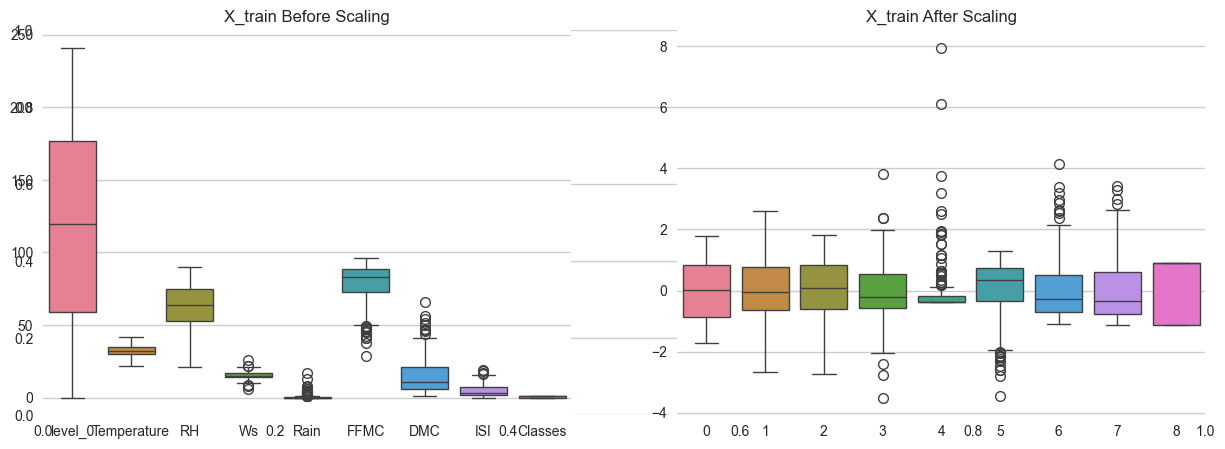

In [48]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model 

Mean absolute error :  0.8350473254285599
R2 score :  0.9779385775839652


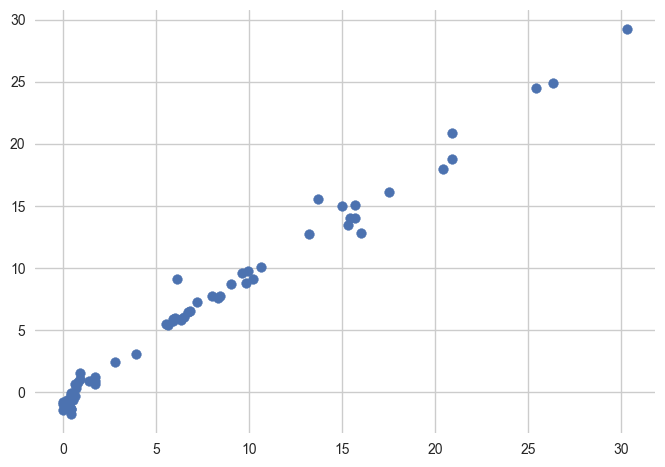

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean absolute error : ',mae)
print('R2 score : ',score)

plt.scatter(y_test,y_pred)

## Lasso Regression 

Mean absolute error :  1.1673161589603014
R2 score :  0.9466140179052819


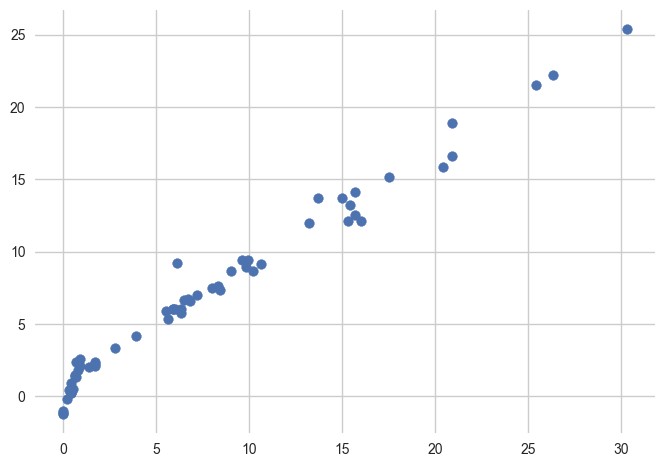

In [54]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean absolute error : ',mae)
print('R2 score : ',score)

plt.scatter(y_test,y_pred)

### Cross Validation Lasso 

In [58]:
from sklearn.linear_model import LassoCV
lassoCV=LassoCV()
lassoCV.fit(x_train_scaled,y_train)


,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,None
,verbose,False
,n_jobs,None


In [63]:
lassoCV.mse_path_

array([[45.97999642, 40.13095114, 36.98993305, 81.69701823, 65.62124421],
       [40.95299205, 35.59811105, 31.70057291, 81.69701823, 62.66839123],
       [35.99582012, 31.55864898, 27.19334305, 75.40519   , 56.13632957],
       [31.66759028, 28.01909758, 23.36010162, 68.5789962 , 50.43861118],
       [27.88746209, 24.91622358, 20.10717175, 62.55546623, 45.46767167],
       [24.58509981, 22.1947383 , 17.35355251, 57.2358791 , 39.93534955],
       [21.699139  , 19.80649966, 15.0290935 , 52.53397961, 34.93788837],
       [19.1764982 , 17.70947235, 13.0731448 , 48.18143521, 30.589185  ],
       [16.97059179, 15.86718389, 11.43319977, 42.36133476, 26.8049408 ],
       [15.04096287, 14.24763524, 10.06410811, 37.28523484, 23.51133962],
       [13.35237037, 12.82297489,  8.9266724 , 32.85701281, 20.64545274],
       [11.8741132 , 11.56890078,  7.98712488, 28.99317747, 18.1512579 ],
       [10.57931661, 10.46420331,  7.21633837, 25.62105218, 15.98044886],
       [ 9.44493951,  9.49036739,  6.5

Mean Absolute Error  0.8573647007078319
R2 Score  0.9769042130417694


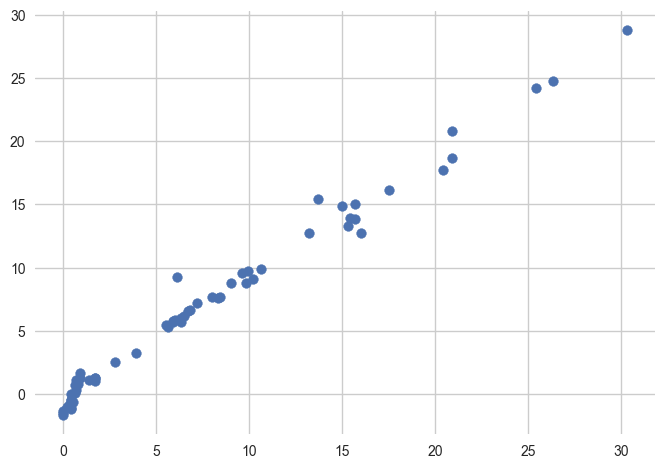

In [69]:
y_pred=lassoCV.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean Absolute Error ' , mae)
print('R2 Score ' , score)


## Ridge Regression Model 

Mean absolute error :  0.8450323463784937
R2 score :  0.9774272005905444


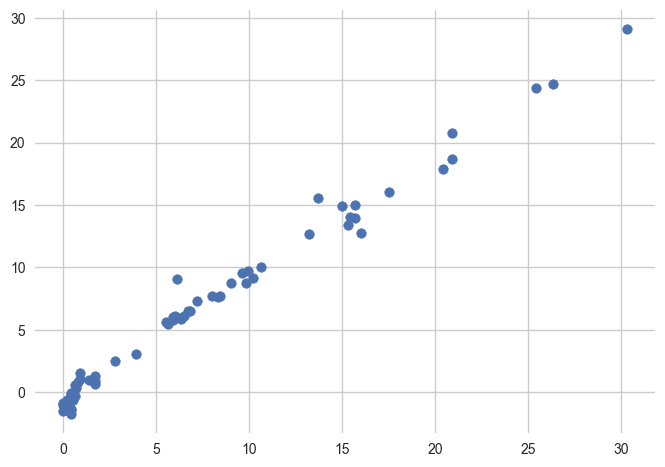

In [55]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean absolute error : ',mae)
print('R2 score : ',score)

plt.scatter(y_test,y_pred)

Mean Absolute Error  0.9400141660343713
R2 Score  0.9708666049078756


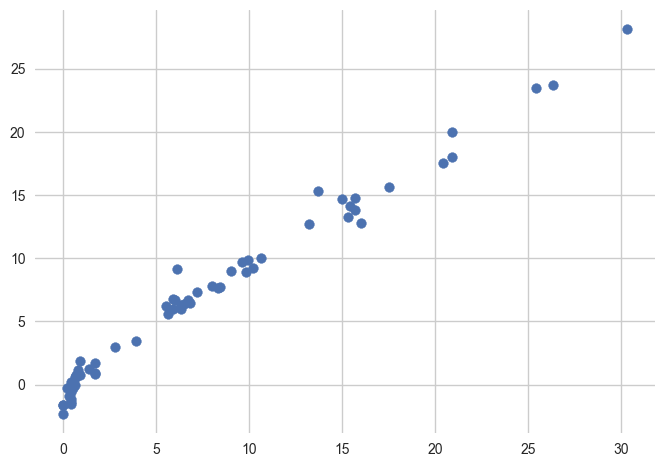

In [73]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaled,y_train)
y_pred=ridgecv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean Absolute Error ', mae)
print("R2 Score " , score)


In [76]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## Elasticnet Regression

Mean absolute error :  1.7817470167645433
R2 score :  0.8830898866985433


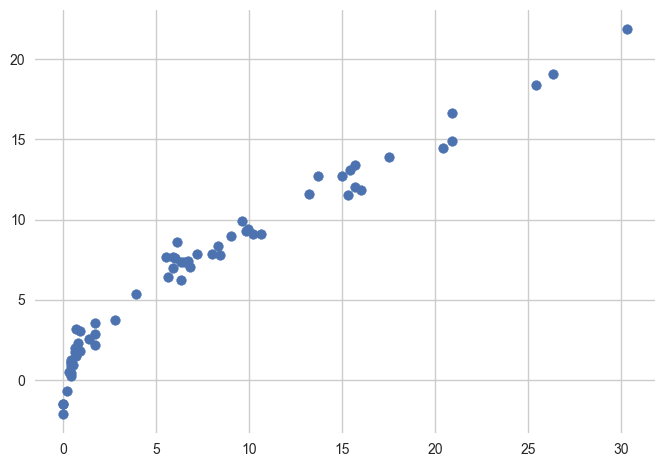

In [56]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


elastic=ElasticNet()
elastic.fit(x_train_scaled,y_train)
y_pred=elastic.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean absolute error : ',mae)
print('R2 score : ',score)

plt.scatter(y_test,y_pred)

Mean Absolute Error  0.8690006308955668
R2 Score  0.9756760868581993


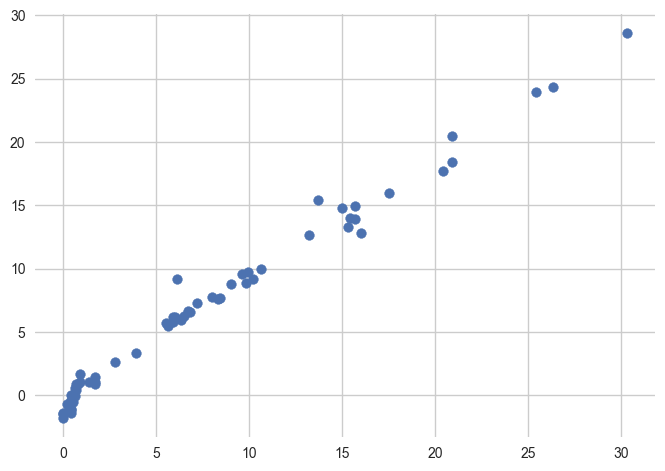

In [77]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(x_train_scaled,y_train)
y_pred=elasticcv.predict(x_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print('Mean Absolute Error ', mae)
print("R2 Score " , score)


In [79]:
elasticcv.alphas_

array([13.52679383, 12.6151332 , 11.76491544, 10.97199952, 10.23252347,
        9.54288564,  8.89972709,  8.29991527,  7.74052876,  7.21884302,
        6.73231717,  6.27858152,  5.85542614,  5.46079002,  5.09275104,
        4.74951667,  4.42941514,  4.13088739,  3.8524794 ,  3.59283518,
        3.35069012,  3.12486482,  2.91425939,  2.71784806,  2.5346742 ,
        2.36384564,  2.20453035,  2.05595239,  1.91738808,  1.78816254,
        1.66764637,  1.55525258,  1.45043376,  1.35267938,  1.26151332,
        1.17649154,  1.09719995,  1.02325235,  0.95428856,  0.88997271,
        0.82999153,  0.77405288,  0.7218843 ,  0.67323172,  0.62785815,
        0.58554261,  0.546079  ,  0.5092751 ,  0.47495167,  0.44294151,
        0.41308874,  0.38524794,  0.35928352,  0.33506901,  0.31248648,
        0.29142594,  0.27178481,  0.25346742,  0.23638456,  0.22045304,
        0.20559524,  0.19173881,  0.17881625,  0.16676464,  0.15552526,
        0.14504338,  0.13526794,  0.12615133,  0.11764915,  0.10